In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import seaborn as sns

In [35]:
demo_raw = pd.read_csv("../data/BlackFriday-Demographic.csv")
click_raw = pd.read_csv("../data/Click_Button.csv")
purchase_raw = pd.read_csv("../data/Purchases.csv")

print("Raw demographic shape:", demo_raw.shape)
print("Raw clickstream shape:", click_raw.shape)
print("Raw purchase shape:", purchase_raw.shape)

Raw demographic shape: (233599, 11)
Raw clickstream shape: (12330, 18)
Raw purchase shape: (74817, 7)


In [36]:
demo = demo_raw.copy()
demo.columns = demo.columns.str.strip()

demo = demo.drop(columns=["User_ID", "Product_ID"], errors="ignore")

for col in ["Product_Category_2", "Product_Category_3"]:
    if col in demo.columns:
        demo[col] = demo[col].fillna(0)

demo = demo.drop_duplicates()

print("Clean demographic shape:", demo.shape)
display(demo.head())

Clean demographic shape: (91628, 9)


,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,M,46-50,7,B,2,1,1,11.0,0.0
1,M,26-35,17,C,0,0,3,5.0,0.0
2,F,36-45,1,B,4+,1,5,14.0,0.0
3,F,36-45,1,B,4+,1,4,9.0,0.0
4,F,26-35,1,C,1,0,4,5.0,12.0


In [37]:
click = click_raw.copy()
click.columns = click.columns.str.strip()

click = click.drop(columns=["Revenue"], errors="ignore")

if "Weekend" in click.columns:
    click["Weekend"] = click["Weekend"].astype(int)

click = click.drop_duplicates()

print("Clean clickstream shape:", click.shape)
display(click.head())

Clean clickstream shape: (12205, 17)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1


^^The rows and columns we have before and after cleaning the dataset and after pca

In [38]:
purchase = purchase_raw.copy()
purchase.columns = purchase.columns.str.strip()

if "Timestamp" in purchase.columns:
    purchase["Timestamp"] = pd.to_datetime(purchase["Timestamp"], errors="coerce")
    purchase["hour"] = purchase["Timestamp"].dt.hour
    purchase["day_of_week"] = purchase["Timestamp"].dt.dayofweek
    purchase = purchase.drop(columns=["Timestamp"])

purchase = purchase.drop_duplicates()

user_col = None
for possible in ["UserID", "User_ID", "user_id", "UserId"]:
    if possible in purchase.columns:
        user_col = possible
        break

if user_col is None:
    purchase["row_id"] = range(len(purchase))
    user_col = "row_id"

purchase_agg = purchase.groupby(user_col).agg({
    "Amount": ["mean", "sum", "count"],
    "hour": "mean",
    "day_of_week": "mean"
})

purchase_agg.columns = ["Amount_mean", "Amount_sum", "Amount_count", "avg_hour", "avg_day_of_week"]
purchase_agg = purchase_agg.reset_index(drop=True)

print("Clean purchase aggregate shape:", purchase_agg.shape)
display(purchase_agg.head())

Clean purchase aggregate shape: (1000, 5)


,Amount_mean,Amount_sum,Amount_count,avg_hour,avg_day_of_week
0,249.516097,1996.128780,8,13.890244,3.158537
1,205.888748,2676.553720,13,11.671233,3.287671
2,252.116565,1512.699392,6,13.406250,3.187500
3,258.091818,2322.826358,9,10.963855,3.048193
4,312.759478,2189.316345,7,11.785714,2.916667


In [39]:
demo_encoded = pd.get_dummies(demo, drop_first=True)
click_encoded = pd.get_dummies(click, drop_first=True)
purchase_encoded = pd.get_dummies(purchase_agg, drop_first=True)

demo_encoded = demo_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)
click_encoded = click_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)
purchase_encoded = purchase_encoded.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Encoded demographic shape:", demo_encoded.shape)
print("Encoded clickstream shape:", click_encoded.shape)
print("Encoded purchase shape:", purchase_encoded.shape)

Encoded demographic shape: (91628, 18)
Encoded clickstream shape: (12205, 26)
Encoded purchase shape: (1000, 5)


In [40]:
demo_scaler = StandardScaler()
click_scaler = StandardScaler()
purchase_scaler = StandardScaler()

demo_scaled = demo_scaler.fit_transform(demo_encoded)
click_scaled = click_scaler.fit_transform(click_encoded)
purchase_scaled = purchase_scaler.fit_transform(purchase_encoded)

In [41]:
demo_pca_model = PCA(n_components=0.90, random_state=42)
click_pca_model = PCA(n_components=0.90, random_state=42)
purchase_pca_model = PCA(n_components=0.90, random_state=42)

demo_pca = demo_pca_model.fit_transform(demo_scaled)
click_pca = click_pca_model.fit_transform(click_scaled)
purchase_pca = purchase_pca_model.fit_transform(purchase_scaled)

print("Demographic PCA shape:", demo_pca.shape)
print("Clickstream PCA shape:", click_pca.shape)
print("Purchase PCA shape:", purchase_pca.shape)

Demographic PCA shape: (91628, 14)
Clickstream PCA shape: (12205, 19)
Purchase PCA shape: (1000, 4)



--- Predicting Purchase Intention (Clickstream) ---
Accuracy: 0.8546
F1-Score (Weighted): 0.8402

Detailed Report:
               precision    recall  f1-score   support

       False       0.89      0.95      0.92      2079
        True       0.52      0.32      0.40       362

    accuracy                           0.85      2441
   macro avg       0.70      0.64      0.66      2441
weighted avg       0.83      0.85      0.84      2441



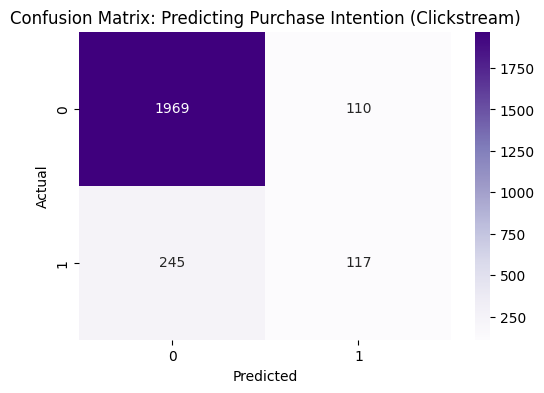


--- Predicting City Category (Demographics) ---
Accuracy: 0.9193
F1-Score (Weighted): 0.9190

Detailed Report:
               precision    recall  f1-score   support

           A       0.89      0.82      0.85      4534
           B       0.98      0.97      0.98      7172
           C       0.87      0.93      0.90      6620

    accuracy                           0.92     18326
   macro avg       0.92      0.91      0.91     18326
weighted avg       0.92      0.92      0.92     18326



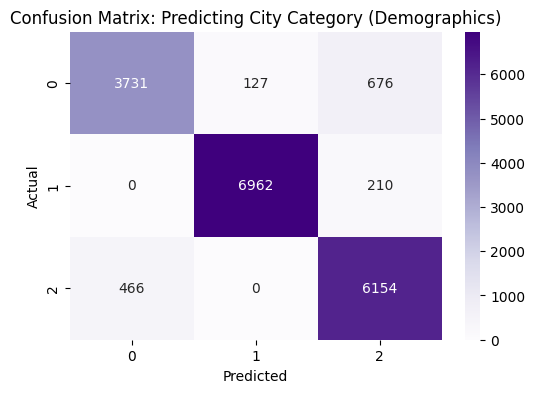

In [42]:
# NAIVE BAYES MODEL!
y_click = click_raw.loc[click.index, 'Revenue']
y_demo = demo_raw.loc[demo.index, 'City_Category']
def evaluate_nb_model(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n--- {title} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print("\nDetailed Report:\n", classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_nb_model(click_pca, y_click, "Predicting Purchase Intention (Clickstream)")
evaluate_nb_model(demo_pca, y_demo, "Predicting City Category (Demographics)")



In [43]:
def run_kmeans_range(X, min_k=2, max_k=8):
    results = []

    for k in range(min_k, max_k + 1):
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            random_state=42,
            n_init=10
        )

        labels = model.fit_predict(X)

        score = silhouette_score(X, labels)

        results.append({
            "k": k,
            "wcss": model.inertia_,
            "silhouette": score
        })

    return pd.DataFrame(results)

In [44]:
demo_scores = run_kmeans_range(demo_pca)
click_scores = run_kmeans_range(click_pca)
purchase_scores = run_kmeans_range(purchase_pca)

print("Demographic scores")
display(demo_scores)

print("Clickstream scores")
display(click_scores)

print("Purchase scores")
display(purchase_scores)

Demographic scores


,k,wcss,silhouette
0,2,1.411499e+06,0.085629
1,3,1.299446e+06,0.110926
2,4,1.183131e+06,0.146900
3,5,1.086487e+06,0.176453
4,6,1.059431e+06,0.165950
5,7,9.380036e+05,0.195099
6,8,8.954901e+05,0.185609


Clickstream scores


,k,wcss,silhouette
0,2,267007.354880,0.187285
1,3,248272.826894,0.202720
2,4,235146.064699,0.064036
3,5,221647.970510,0.094810
4,6,208024.097034,0.137232
5,7,195810.173855,0.149649
6,8,184903.628013,0.177581


Purchase scores


,k,wcss,silhouette
0,2,3689.207991,0.232967
1,3,3171.689432,0.195327
2,4,2844.502314,0.187787
3,5,2592.712438,0.179116
4,6,2366.136019,0.184878
5,7,2199.232186,0.180285
6,8,2073.527328,0.177139


In [45]:
demo_k = int(demo_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
click_k = int(click_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
purchase_k = int(purchase_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])

print("Chosen demographic k:", demo_k)
print("Chosen clickstream k:", click_k)
print("Chosen purchase k:", purchase_k)

demo_kmeans = KMeans(n_clusters=demo_k, init="k-means++", random_state=42, n_init=10)
click_kmeans = KMeans(n_clusters=click_k, init="k-means++", random_state=42, n_init=10)
purchase_kmeans = KMeans(n_clusters=purchase_k, init="k-means++", random_state=42, n_init=10)

demo_labels = demo_kmeans.fit_predict(demo_pca)
click_labels = click_kmeans.fit_predict(click_pca)
purchase_labels = purchase_kmeans.fit_predict(purchase_pca)

Chosen demographic k: 7
Chosen clickstream k: 3
Chosen purchase k: 2


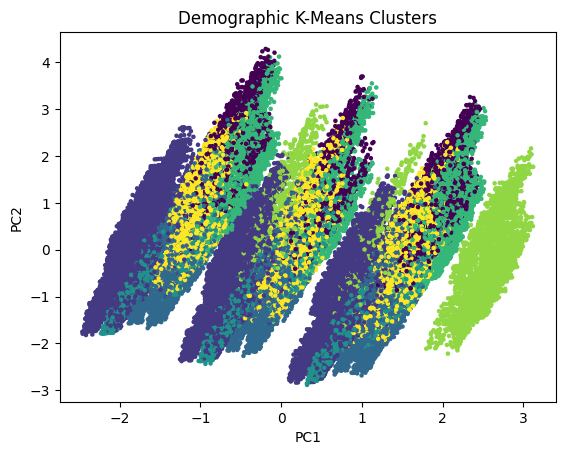

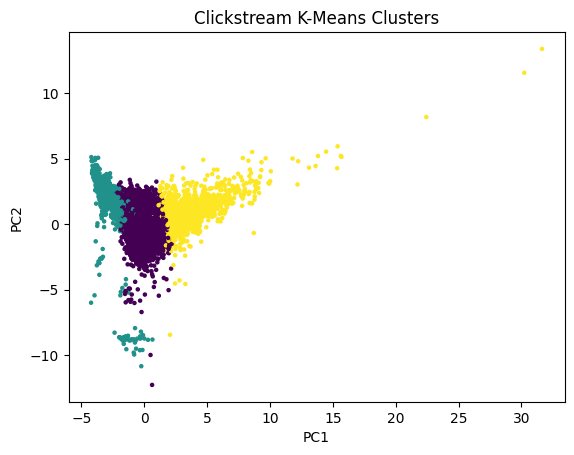

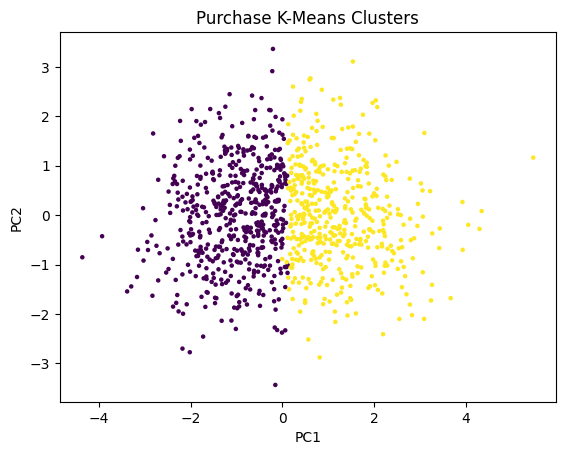

In [46]:
plt.figure()
plt.scatter(demo_pca[:, 0], demo_pca[:, 1], c=demo_labels, s=5)
plt.title("Demographic K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(click_pca[:, 0], click_pca[:, 1], c=click_labels, s=5)
plt.title("Clickstream K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(purchase_pca[:, 0], purchase_pca[:, 1], c=purchase_labels, s=5)
plt.title("Purchase K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [47]:
demo_labeled = demo.copy()
demo_labeled["cluster"] = demo_labels

click_labeled = click.copy()
click_labeled["cluster"] = click_labels

purchase_labeled = purchase_agg.copy()
purchase_labeled["cluster"] = purchase_labels

In [48]:
print("Demographic cluster sizes")
display(demo_labeled["cluster"].value_counts().sort_index())

print("Clickstream cluster sizes")
display(click_labeled["cluster"].value_counts().sort_index())

print("Purchase cluster sizes")
display(purchase_labeled["cluster"].value_counts().sort_index())

Demographic cluster sizes


cluster
0     7993
1    29625
2    14681
3     8687
4     9084
5     4795
6    16763
Name: count, dtype: int64

Clickstream cluster sizes


cluster
0    9584
1    1030
2    1591
Name: count, dtype: int64

Purchase cluster sizes


cluster
0    542
1    458
Name: count, dtype: int64

In [49]:
import pandas as pd

df = pd.read_csv('demographic_clustered.csv')
numeric_summary = df.groupby('cluster').mean(numeric_only=True)

categorical_summary = df.groupby('cluster')[['Age', 'Gender', 'City_Category']].agg(lambda x: x.mode()[0])

cluster_profiles = pd.concat([categorical_summary, numeric_summary], axis=1)

print("--- CLUSTER PERSONA BREAKDOWN ---")
print(cluster_profiles)

--- CLUSTER PERSONA BREAKDOWN ---
           Age Gender City_Category  Occupation  Marital_Status  \
cluster                                                           
0        18-25      M             B    7.770247        0.266194   
1        36-45      M             B    8.929596        0.400309   
2        26-35      M             B    8.549259        0.387315   
3        46-50      M             C    8.519044        0.699362   
4        51-55      M             B    8.752533        0.707369   
5          55+      M             C    9.276955        0.615641   
6        26-35      M             B    8.771621        0.389973   
7        26-35      M             B    8.279498        0.396530   

         Product_Category_1  Product_Category_2  Product_Category_3  
cluster                                                              
0                  4.661808            8.102037            6.267897  
1                  5.018582            8.441201            5.919244  
2              

In [50]:
age_gender_profile = pd.crosstab(
    demo_labeled["cluster"],
    [demo_labeled["Gender"], demo_labeled["Age"]],
    normalize="index"
)

display(age_gender_profile)

Gender          F                                                             \
Age          0-17     18-25     26-35     36-45     46-50    51-55       55+   
cluster                                                                        
0        0.000000  0.000000  0.000000  0.000000  0.000000  0.26886  0.000000   
1        0.025924  0.000000  0.243308  0.000000  0.000000  0.00000  0.000000   
2        0.000000  0.264015  0.000000  0.000000  0.000000  0.00000  0.000000   
3        0.005525  0.000000  0.172557  0.094164  0.000000  0.00000  0.000000   
4        0.000000  0.000000  0.000000  0.000000  0.303611  0.00000  0.000000   
5        0.000000  0.000000  0.000000  0.000000  0.000000  0.00000  0.250052   
6        0.000000  0.000000  0.000000  0.290759  0.000000  0.00000  0.000000   

Gender          M                                                             
Age          0-17     18-25     26-35     36-45     46-50    51-55       55+  
cluster                                                                       
0        0.000000  0.000000  0.000000  0.000000  0.000000  0.73114  0.000000  
1        0.046211  0.000000  0.684557  0.000000  0.000000  0.00000  0.000000  
2        0.000000  0.735985  0.000000  0.000000  0.000000  0.00000  0.000000  
3        0.023944  0.000000  0.465523  0.238287  0.000000  0.00000  0.000000  
4        0.000000  0.000000  0.000000  0.000000  0.696389  0.00000  0.000000  
5        0.000000  0.000000  0.000000  0.000000  0.000000  0.00000  0.749948  
6        0.000000  0.000000  0.000000  0.709241  0.000000  0.00000  0.000000

In [51]:
print("Demo columns:", demo_profile.columns.tolist())
print("Click columns:", click_profile.columns.tolist())
print("Purchase columns:", purchase_profile.columns.tolist())

Demo columns: ['Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']
Click columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']
Purchase columns: ['Amount_mean', 'Amount_sum', 'Amount_count', 'hour_mean', 'day_of_week_mean', 'EventType_add_to_cart_count', 'EventType_click_count', 'EventType_login_count', 'EventType_logout_count', 'EventType_page_view_count', 'EventType_product_view_count', 'EventType_purchase_count', 'ProductID_prod_1000_count', 'ProductID_prod_1001_count', 'ProductID_prod_1002_count', 'ProductID_prod_1004_count', 'ProductID_prod_1005_count', 'ProductID_prod_1006_count', 'ProductID_prod_1007_count', 'ProductID_prod_1008_count', 'ProductID_prod_1009_count', 'ProductID_prod_1010_count', 'ProductID_prod_1011_count', 'Pr

In [52]:
# --- DEMOGRAPHIC SUMMARY ---
demo_summary = pd.DataFrame({
    "segment_type": "demographic",
    "cluster": demo_profile.index
})

if "Purchase" in demo_profile.columns:
    demo_summary["avg_purchase"] = demo_profile["Purchase"].values

if "Marital_Status" in demo_profile.columns:
    demo_summary["avg_marital_status"] = demo_profile["Marital_Status"].values


# --- CLICKSTREAM SUMMARY ---
click_summary = pd.DataFrame({
    "segment_type": "clickstream",
    "cluster": click_profile.index
})

for col in ["ProductRelated", "ProductRelated_Duration", "BounceRates", "PageValues"]:
    if col in click_profile.columns:
        click_summary[f"avg_{col}"] = click_profile[col].values


# --- PURCHASE SUMMARY ---
purchase_summary = pd.DataFrame({
    "segment_type": "purchase",
    "cluster": purchase_profile.index
})

for col in ["Amount_mean", "Amount_sum", "Amount_count"]:
    if col in purchase_profile.columns:
        purchase_summary[col] = purchase_profile[col].values


# --- DISPLAY ---
display(demo_summary)
display(click_summary)
display(purchase_summary)

,segment_type,cluster,avg_marital_status
0,demographic,0,0.266194
1,demographic,1,0.400309
2,demographic,2,0.387315
3,demographic,3,0.699362
4,demographic,4,0.707369
5,demographic,5,0.615641
6,demographic,6,0.389973
7,demographic,7,0.396530


,segment_type,cluster,avg_ProductRelated,avg_ProductRelated_Duration,avg_BounceRates,avg_PageValues
0,clickstream,0,92.901130,4292.479068,0.007465,7.406016
1,clickstream,1,27.088715,1031.780548,0.009551,6.859522
2,clickstream,2,1.363636,0.000000,0.200000,0.000000
3,clickstream,3,44.828302,1676.290783,0.010703,7.342079
4,clickstream,4,25.725307,931.588026,0.016302,5.582819
5,clickstream,5,33.566485,1116.977684,0.011849,8.645580
6,clickstream,6,20.104443,811.177136,0.008514,4.235160
7,clickstream,7,32.615452,1111.824245,0.022256,5.177568


,segment_type,cluster,Amount_mean,Amount_sum,Amount_count
0,purchase,0,232.387758,2504.252860,10.555556
1,purchase,1,253.678709,2706.392254,10.683148


In [53]:
# Find the correct purchase/spending column name automatically
possible_purchase_cols = ["Purchase", "purchase", "Purchase_Amount", "Amount", "amount"]

purchase_col = None
for col in possible_purchase_cols:
    if col in demo_labeled.columns:
        purchase_col = col
        break

print("Using purchase column:", purchase_col)

if purchase_col is not None:
    demo_labeled["spending_segment"] = pd.qcut(
        demo_labeled[purchase_col],
        q=3,
        labels=["low_spend", "medium_spend", "high_spend"],
        duplicates="drop"
    )

    demo_spend_by_cluster = pd.crosstab(
        demo_labeled["cluster"],
        demo_labeled["spending_segment"],
        normalize="index"
    )

    display(demo_spend_by_cluster)

    demo_spend_by_cluster.plot(
        kind="bar",
        title="Spending Level by Demographic Cluster"
    )
    plt.ylabel("Proportion of Cluster")
    plt.show()

else:
    print("No purchase/spending column found. Run this to check column names:")
    print(demo_labeled.columns.tolist())

Using purchase column: None
No purchase/spending column found. Run this to check column names:
['Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'cluster']


In [54]:
pattern_comparison = pd.DataFrame()

# DEMOGRAPHIC
if "demo_spend_by_cluster" in globals():
    if "high_spend" in demo_spend_by_cluster.columns:
        pattern_comparison["demo_high_spend_share"] = demo_spend_by_cluster["high_spend"].reset_index(drop=True)

# CLICKSTREAM
if "click_engagement_by_cluster" in globals():
    if "high_engagement" in click_engagement_by_cluster.columns:
        pattern_comparison["click_high_engagement_share"] = click_engagement_by_cluster["high_engagement"].reset_index(drop=True)

# PURCHASE
if "purchase_value_by_cluster" in globals():
    if "high_value" in purchase_value_by_cluster.columns:
        pattern_comparison["purchase_high_value_share"] = purchase_value_by_cluster["high_value"].reset_index(drop=True)

display(pattern_comparison)

if len(pattern_comparison.columns) > 1:
    corr_matrix = pattern_comparison.corr()
    display(corr_matrix)
else:
    print("Not enough data for correlation yet.")

,click_high_engagement_share,purchase_high_value_share
0,0.278694,0.000000
1,0.023301,0.729258
2,0.863608,NaN


,click_high_engagement_share,purchase_high_value_share
click_high_engagement_share,1.0,-1.0
purchase_high_value_share,-1.0,1.0


In [55]:
demo_labeled.to_csv("demographic_kmeans_clustered.csv", index=False)
click_labeled.to_csv("clickstream_kmeans_clustered.csv", index=False)
purchase_labeled.to_csv("purchase_kmeans_clustered.csv", index=False)

demo_summary.to_csv("demographic_cluster_summary.csv", index=False)
click_summary.to_csv("clickstream_cluster_summary.csv", index=False)
purchase_summary.to_csv("purchase_cluster_summary.csv", index=False)

pattern_comparison.to_csv("segment_pattern_comparison.csv", index=False)
corr_matrix.to_csv("segment_pattern_correlations.csv")

print("All files saved.")

All files saved.


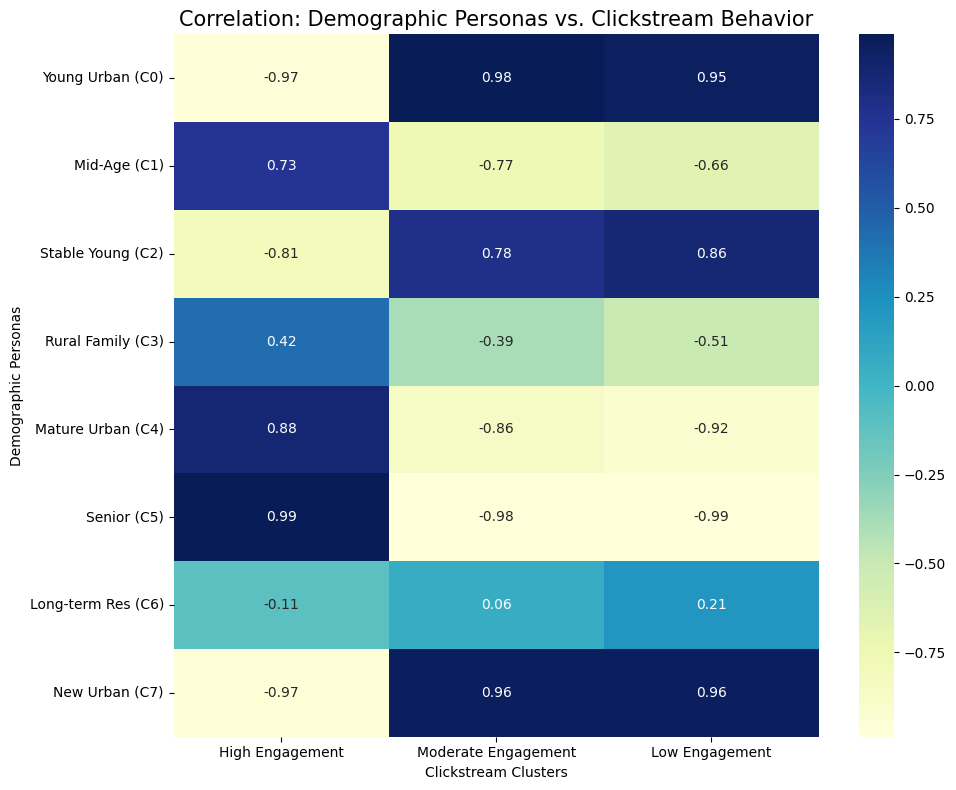

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

demo_df = pd.read_csv('demographic_clustered.csv')
click_df = pd.read_csv('clickstream_clustered.csv') # Ensure this file is in your folder

demo_profile = demo_df.groupby('cluster').mean(numeric_only=True)
click_profile = click_df.groupby('cluster').mean(numeric_only=True)

pca = PCA(n_components=3)
demo_reduced = pca.fit_transform(demo_profile)
click_reduced = pca.fit_transform(click_profile)

matrix_values = cosine_similarity(demo_reduced, click_reduced)
demo_labels = [
    "Young Urban (C0)", "Mid-Age (C1)", "Stable Young (C2)", 
    "Rural Family (C3)", "Mature Urban (C4)", "Senior (C5)", 
    "Long-term Res (C6)", "New Urban (C7)"
]
plt.figure(figsize=(10, 8))

sns.heatmap(matrix_values[:, :3], 
            annot=True, 
            cmap='YlGnBu', 
            xticklabels=['High Engagement', 'Moderate Engagement', 'Low Engagement'],
            yticklabels=demo_labels,
            fmt=".2f")
plt.title("Correlation: Demographic Personas vs. Clickstream Behavior", fontsize=15)
plt.xlabel("Clickstream Clusters")
plt.ylabel("Demographic Personas")
plt.tight_layout()
plt.show()

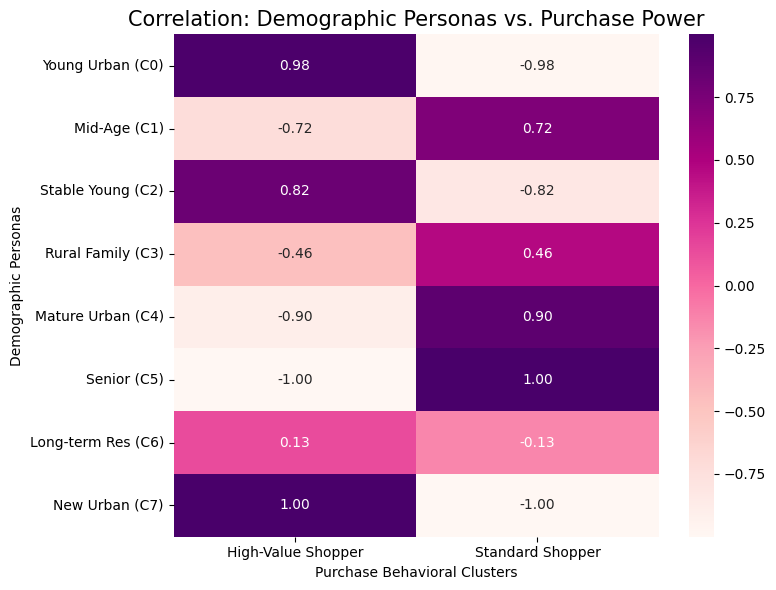

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

demo_df = pd.read_csv('demographic_clustered.csv')
purchase_df = pd.read_csv('purchase_clustered.csv')

# group into centroids
demo_profile = demo_df.groupby('cluster').mean(numeric_only=True)
purchase_profile = purchase_df.groupby('cluster').mean(numeric_only=True)

pca = PCA(n_components=2)
demo_reduced = pca.fit_transform(demo_profile)
purchase_reduced = pca.fit_transform(purchase_profile)

matrix_values = cosine_similarity(demo_reduced, purchase_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(matrix_values, 
            annot=True, 
            cmap='RdPu', 
            xticklabels=['High-Value Shopper', 'Standard Shopper'],
            yticklabels=demo_labels, 
            fmt=".2f")

plt.title("Correlation: Demographic Personas vs. Purchase Power", fontsize=15)
plt.xlabel("Purchase Behavioral Clusters")
plt.ylabel("Demographic Personas")
plt.tight_layout()
plt.show()

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.stats import mode
import numpy as np

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(demo_pca)

y_true = demo_raw.loc[demo.index, 'City_Category']

def map_clusters_to_labels(clusters, y_true):
    labels = np.zeros_like(clusters, dtype=object)
    
    # Loop through each unique cluster found by K-Means
    for i in np.unique(clusters):
        mask = (clusters == i)
        if np.any(mask):
            most_frequent_label = y_true[mask].value_counts().idxmax()
            labels[mask] = most_frequent_label
    return labels

y_pred = map_clusters_to_labels(clusters, y_true)

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"K-Means Accuracy (after mapping): {accuracy:.4f}")
print(f"K-Means F1-Score (weighted): {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))

K-Means Accuracy (after mapping): 0.3974
K-Means F1-Score (weighted): 0.3318


/opt/homebrew/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00     22823
           B       0.40      0.36      0.38     35897
           C       0.40      0.71      0.51     32908

    accuracy                           0.40     91628
   macro avg       0.26      0.36      0.30     91628
weighted avg       0.30      0.40      0.33     91628



/opt/homebrew/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
